# CREDIT CARD FRAUD DETECTION

**DataSet Source**: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud 

**Business problem:** Every missed fraud (false negative) costs the bank real money. Every false positive (legitimate transaction flagged) frustrates customers. The goal is to maximise recall on the fraud class while keeping precision high enough to be operationally useful.

**Approach:**
1. Importing Libraries
2. Importing CSV File
3. Data Preprocessing
4. Exploratory Data Analysis(EDA)
5. Feature Engineering & Train/Test Split
6. Model Pipeline
7. Save Best Model
8. Conclusion

# 1. IMPORTING LIBRARIES

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pickle

# 2. IMPORTING CSV FILE

In [2]:
card_file= pd.read_csv("creditcard.csv")

# 3. DATA PREPROCESSING

The dataset contains 30 numeric features: `Time`, `Amount`, and V1–V28 (PCA-transformed for anonymity).  
The target column is `Class` (1 = fraud, 0 = legitimate).

## 3.1 Basic Insights of Data

In [3]:
card_file.shape

(284807, 31)

In [4]:
card_file.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
card_file.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [6]:
card_file.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
card_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
card_file.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
card_file.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

## 3.2 Finding Duplicates

In [10]:
card_file[card_file.duplicated()]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282987,171288.0,1.912550,-0.455240,-1.750654,0.454324,2.089130,4.160019,-0.881302,1.081750,1.022928,...,-0.524067,-1.337510,0.473943,0.616683,-0.283548,-1.084843,0.073133,-0.036020,11.99,0
283483,171627.0,-1.464380,1.368119,0.815992,-0.601282,-0.689115,-0.487154,-0.303778,0.884953,0.054065,...,0.287217,0.947825,-0.218773,0.082926,0.044127,0.639270,0.213565,0.119251,6.82,0
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284191,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0


### 3.2.1 Drop Duplicates

User might have entered the same information more than once dropping that duplicate columns 

In [11]:
card_file=card_file.drop_duplicates() 

check if all duplicates are dropped 

In [12]:
card_file.duplicated().sum()

np.int64(0)

## 3.3. Outlier detection

We inspect outliers using the IQR method. Because many V-features are PCA-transformed,  
extreme values are expected and **not removed** — they may encode legitimate variation.  


In [15]:
for col in card_file.columns:
    if col=="Class":
        continue
    skewness=card_file[col].skew()
    Q1=card_file[col].quantile(0.25)
    Q3=card_file[col].quantile(0.75)
    IQR=Q3 - Q1
    upper=Q3 + 1.5* IQR
    lower=Q1 - 1.5* IQR

    outliers=card_file[(card_file[col]>upper) | (card_file[col]< lower)]
    print(f"column: {col}")
    print(f"skewness: {skewness}")
    print(f"outliers: {len(outliers)}")

column: Time
skewness: -0.03558064623598201
outliers: 0
column: V1
skewness: -3.273271248440311
outliers: 6948
column: V2
skewness: -4.695161900540468
outliers: 13390
column: V3
skewness: -2.151983957099712
outliers: 3306
column: V4
skewness: 0.6715041706728239
outliers: 11094
column: V5
skewness: -2.414079246966253
outliers: 12221
column: V6
skewness: 1.8298803837715212
outliers: 22886
column: V7
skewness: 2.8902711927154967
outliers: 8839
column: V8
skewness: -8.310970330052546
outliers: 23904
column: V9
skewness: 0.5376630534496958
outliers: 8199
column: V10
skewness: 1.2529670787468168
outliers: 9345
column: V11
skewness: 0.34407419325686256
outliers: 735
column: V12
skewness: -2.1990082816149945
outliers: 15282
column: V13
skewness: 0.06429340464018107
outliers: 3362
column: V14
skewness: -1.9188037137586458
outliers: 14060
column: V15
skewness: -0.3096590822936595
outliers: 2884
column: V16
skewness: -1.051161471517466
outliers: 8180
column: V17
skewness: -3.690497194148407
outli

# 4. EXPLORATORY DATA ANALYSIS

## 4.1 Data visualization

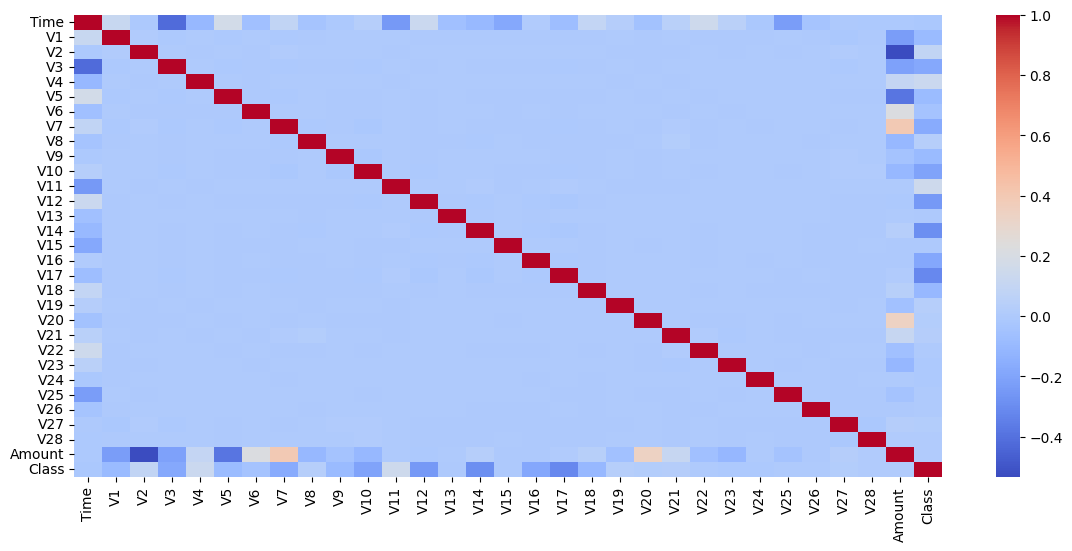

In [16]:
plt.figure(figsize=(14,6))
sns.heatmap(card_file.corr(),cmap="coolwarm")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_25636\3602655771.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


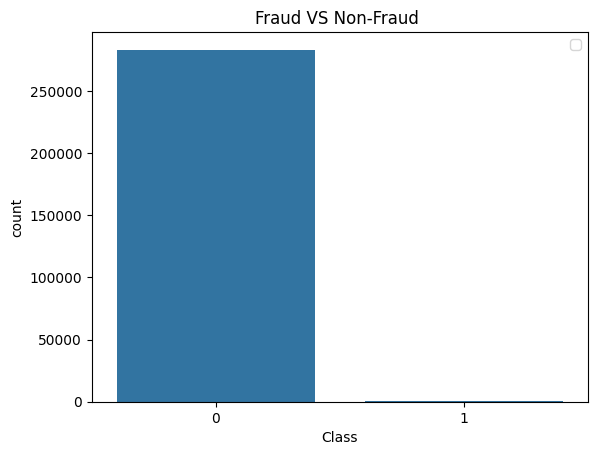

In [17]:
sns.countplot(x='Class',data=card_file)
plt.legend()
plt.title("Fraud VS Non-Fraud ")
plt.show()

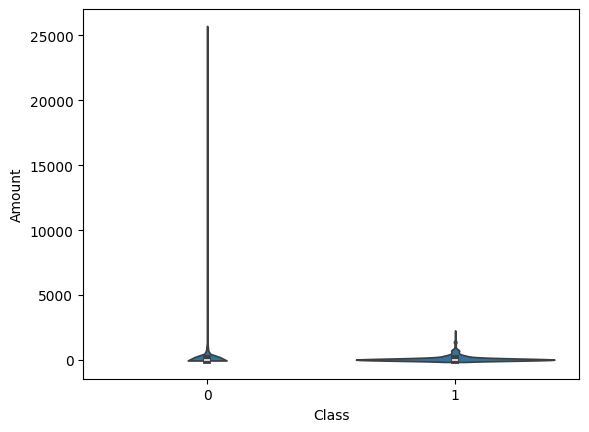

In [18]:
sns.violinplot(x="Class",y="Amount",data=card_file)
plt.show()

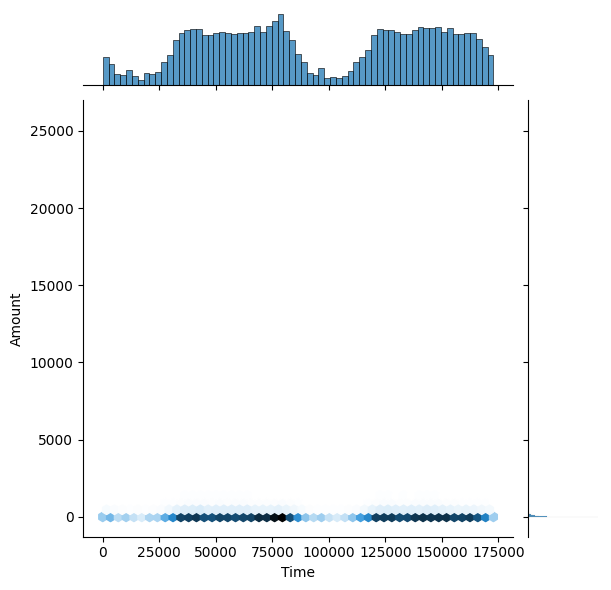

In [19]:
sns.jointplot(x='Time',
              y='Amount',
              data=card_file,
              kind='hex')

# 5. Feature Engineering & Train/Test Split

In [20]:
X=card_file.drop(columns=["Class"])
Y=card_file["Class"]

In [95]:
X_train,X_test,Y_train,Y_test = train_test_split( X, Y, test_size=0.2 , random_state=42,stratify=Y)

Y_test

86568     0
251557    0
20232     0
68952     0
191852    0
         ..
56516     0
188431    0
115561    0
187644    0
8267      0
Name: Class, Length: 56746, dtype: int64

# 6. MODEL PIPELINE
Using sklearn `Pipeline` to chain scaling → feature selection → classifier.  
This guarantees the scaler is only fit on training data, preventing data leakage.

## 6.1 Feature Scaling and Log Transformation

Not scaling slice(0,30) because log-transformer is also applied on  Amount and Time which are already inside that slice. 
So those two columns get processed twice. Thwrefore processing from slice(1,29)



In [96]:
robust_log_scaler=ColumnTransformer([
    ('Scale',RobustScaler(), slice(1,29) ),
    ('log_trans',FunctionTransformer(func=np.log1p,feature_names_out='one-to-one'),['Amount','Time'])]
        , remainder='passthrough')

## 6.2 Feature selection

In [97]:
feature_selection= SelectKBest(score_func=f_classif,k=28)

## 6.3 Baseline — Logistic Regression with class_weight='balanced'

In [98]:
logistic_regression= LogisticRegression(class_weight = 'balanced')

In [99]:
pipe=Pipeline( [ 
    ( 'robust_log_scaler',robust_log_scaler) , ('feature_selection' , feature_selection) ,('logistic_regression',logistic_regression) 
    ])

In [100]:
pipe.fit(X_train,Y_train)

,steps,"[('robust_log_scaler', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Scale', ...), ('log_trans', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [101]:
X_train_transformed= pipe.named_steps['robust_log_scaler']. transform(X_train)
X_train_transformed

array([[ 0.9952072 , -1.27515307, -1.21677842, ..., -0.46725754,
         3.49650756, 11.88138075],
       [-0.59760034,  1.11731547,  0.21867097, ...,  0.30141238,
         2.07819076, 11.29870449],
       [ 0.84724232, -0.03040158, -1.18362105, ..., -0.49112709,
         2.76945883, 11.7528632 ],
       ...,
       [-0.40056733,  0.7816202 ,  0.20664257, ...,  0.63495076,
         3.63758616, 11.92896777],
       [ 0.55065829,  0.20305738,  0.21470524, ...,  0.15636809,
         1.79175947, 10.80762473],
       [ 0.4509959 , -0.20492001,  0.17946194, ..., -0.09759133,
         2.58851563, 10.86564991]], shape=(226980, 30))

In [102]:
feature_names=pipe.named_steps['robust_log_scaler']. get_feature_names_out()
feature_names

array(['Scale__V1', 'Scale__V2', 'Scale__V3', 'Scale__V4', 'Scale__V5',
       'Scale__V6', 'Scale__V7', 'Scale__V8', 'Scale__V9', 'Scale__V10',
       'Scale__V11', 'Scale__V12', 'Scale__V13', 'Scale__V14',
       'Scale__V15', 'Scale__V16', 'Scale__V17', 'Scale__V18',
       'Scale__V19', 'Scale__V20', 'Scale__V21', 'Scale__V22',
       'Scale__V23', 'Scale__V24', 'Scale__V25', 'Scale__V26',
       'Scale__V27', 'Scale__V28', 'log_trans__Amount', 'log_trans__Time'],
      dtype=object)

#### Convert into Dataframe

In [103]:
X_train_file= pd.DataFrame(X_train_transformed, columns=feature_names, index= X_train.index)
X_train_file.head()

,Scale__V1,Scale__V2,Scale__V3,Scale__V4,Scale__V5,Scale__V6,Scale__V7,Scale__V8,Scale__V9,Scale__V10,...,Scale__V21,Scale__V22,Scale__V23,Scale__V24,Scale__V25,Scale__V26,Scale__V27,Scale__V28,log_trans__Amount,log_trans__Time
226238,0.995207,-1.275153,-1.216778,-1.606746,0.801946,3.294124,-1.624678,1.568787,-0.977940,1.678225,...,-0.291170,-0.053017,0.933343,0.809661,-0.351619,-0.189652,0.224922,-0.467258,3.496508,11.881381
134253,-0.597600,1.117315,0.218671,-0.010285,-0.269912,-0.591514,0.152452,1.335234,-0.981107,-0.392871,...,-0.506390,-0.891313,1.079738,0.596931,-1.090113,-0.379079,-0.119150,0.301412,2.078191,11.298704
186465,0.847242,-0.030402,-1.183621,0.095123,0.930577,0.755626,-0.056210,0.295944,0.271802,-0.408155,...,0.776639,1.016689,-0.107803,-2.177118,0.134448,0.104937,0.269659,-0.491127,2.769459,11.752863
149493,0.803526,0.180212,0.072305,2.453198,0.077371,1.111431,-0.689878,0.395842,0.592835,1.252833,...,0.403806,0.647327,0.597222,0.832635,-0.341895,0.073567,-0.118813,-0.376486,2.906901,11.422377
18461,0.600755,-0.844746,0.194263,-0.959130,-0.875789,0.472816,-1.105189,0.356968,-1.648326,1.602426,...,-0.752328,-0.601434,0.850633,-0.484676,-0.120272,-0.684600,0.376867,0.012462,3.218876,10.292925


#### Model Prediction

In [104]:
y_predict = pipe.predict(X_test)
print("Classification report is: \n", classification_report(Y_test,y_predict))

Classification report is: 
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



### before balancing 

              precision    recall  f1-score   support

         0       1.00      1.00      1.00     56656
         1       0.89      0.53      0.67        90

    accuracy                          1.00      56746

    macro avg       0.94      0.77      0.83      56746

    weighted avg    1.00      1.00      1.00      56746

## 6.4 Random Forest with Class Weight ="balanced"

In [105]:
random_forest=RandomForestClassifier(n_estimators=20,
    max_depth=8,
    n_jobs=-1,
    class_weight='balanced',
    random_state=42)

In [106]:
pipe_rf = Pipeline( [ 
    ( 'robust_log_scaler',robust_log_scaler) , ('feature_selection' , feature_selection) ,('Random forest Classifier',random_forest) 
])

In [107]:
pipe_rf.fit(X_train,Y_train)

,steps,"[('robust_log_scaler', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Scale', ...), ('log_trans', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [108]:
rf_X_train_transformed=pipe_rf.named_steps['robust_log_scaler'].transform(X_train)
rf_X_train_transformed

array([[ 0.9952072 , -1.27515307, -1.21677842, ..., -0.46725754,
         3.49650756, 11.88138075],
       [-0.59760034,  1.11731547,  0.21867097, ...,  0.30141238,
         2.07819076, 11.29870449],
       [ 0.84724232, -0.03040158, -1.18362105, ..., -0.49112709,
         2.76945883, 11.7528632 ],
       ...,
       [-0.40056733,  0.7816202 ,  0.20664257, ...,  0.63495076,
         3.63758616, 11.92896777],
       [ 0.55065829,  0.20305738,  0.21470524, ...,  0.15636809,
         1.79175947, 10.80762473],
       [ 0.4509959 , -0.20492001,  0.17946194, ..., -0.09759133,
         2.58851563, 10.86564991]], shape=(226980, 30))

In [109]:
rf_features_name=pipe_rf.named_steps['robust_log_scaler'].get_feature_names_out()
rf_features_name

array(['Scale__V1', 'Scale__V2', 'Scale__V3', 'Scale__V4', 'Scale__V5',
       'Scale__V6', 'Scale__V7', 'Scale__V8', 'Scale__V9', 'Scale__V10',
       'Scale__V11', 'Scale__V12', 'Scale__V13', 'Scale__V14',
       'Scale__V15', 'Scale__V16', 'Scale__V17', 'Scale__V18',
       'Scale__V19', 'Scale__V20', 'Scale__V21', 'Scale__V22',
       'Scale__V23', 'Scale__V24', 'Scale__V25', 'Scale__V26',
       'Scale__V27', 'Scale__V28', 'log_trans__Amount', 'log_trans__Time'],
      dtype=object)

In [110]:
rf_X_train_df=pd.DataFrame(rf_X_train_transformed,columns=rf_features_name,index=X_train.index)
rf_X_train_df.head()

,Scale__V1,Scale__V2,Scale__V3,Scale__V4,Scale__V5,Scale__V6,Scale__V7,Scale__V8,Scale__V9,Scale__V10,...,Scale__V21,Scale__V22,Scale__V23,Scale__V24,Scale__V25,Scale__V26,Scale__V27,Scale__V28,log_trans__Amount,log_trans__Time
226238,0.995207,-1.275153,-1.216778,-1.606746,0.801946,3.294124,-1.624678,1.568787,-0.977940,1.678225,...,-0.291170,-0.053017,0.933343,0.809661,-0.351619,-0.189652,0.224922,-0.467258,3.496508,11.881381
134253,-0.597600,1.117315,0.218671,-0.010285,-0.269912,-0.591514,0.152452,1.335234,-0.981107,-0.392871,...,-0.506390,-0.891313,1.079738,0.596931,-1.090113,-0.379079,-0.119150,0.301412,2.078191,11.298704
186465,0.847242,-0.030402,-1.183621,0.095123,0.930577,0.755626,-0.056210,0.295944,0.271802,-0.408155,...,0.776639,1.016689,-0.107803,-2.177118,0.134448,0.104937,0.269659,-0.491127,2.769459,11.752863
149493,0.803526,0.180212,0.072305,2.453198,0.077371,1.111431,-0.689878,0.395842,0.592835,1.252833,...,0.403806,0.647327,0.597222,0.832635,-0.341895,0.073567,-0.118813,-0.376486,2.906901,11.422377
18461,0.600755,-0.844746,0.194263,-0.959130,-0.875789,0.472816,-1.105189,0.356968,-1.648326,1.602426,...,-0.752328,-0.601434,0.850633,-0.484676,-0.120272,-0.684600,0.376867,0.012462,3.218876,10.292925


In [111]:
rf_y_predict=pipe_rf.predict(X_test)
print("Classification Report is: \n", classification_report(Y_test,rf_y_predict))

Classification Report is: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.75      0.74      0.74        95

    accuracy                           1.00     56746
   macro avg       0.88      0.87      0.87     56746
weighted avg       1.00      1.00      1.00     56746



before balancing 
Classification Report is: 

               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.98      0.70      0.82        90

    accuracy                           1.00     56746
    macro avg       0.99      0.85      0.91     56746
    weighted avg    1.00      1.00      1.00     56746

# 7. Save Best Model

The Random Forest pipeline is saved  as a single pickle file for deployment.

In [39]:
with open("Credit_card_fraud_detection_model.pkl","wb") as f:
    pickle.dump(pipe_rf,f)

# 8. Conclusion

## 8.1 Limitations 
This model can be deployed because features are PCA-transformed:
- users cannot manually input V1–V28
- deployment realism is limited

## 8.2 Model performance (test set)
| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Recall (fraud) | ~0.897| ~0.74 |
| Precision (fraud) | ~0.06 | ~0.75 |

## 8.3 Potential next steps
1. **SMOTE** — oversample the fraud class and compare to class_weight approach
2. **XGBoost / LightGBM** — gradient boosting often outperforms RF on tabular data
3. **Threshold tuning** — adjust the classification threshold to trade precision for recall based on business cost
4. **Anomaly detection** — try Isolation Forest or Autoencoder as unsupervised baseline
5. **Hyper Parameter Tuning** - better results 